In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

In [ ]:
alpha_cat = 3.0      # cat amplitude
kappa = 1.0          # photon loss rate
N = 80               # Hilbert space truncation
Ntraj = 100          # number of Monte Carlo trajectories

tmax = 10.0 / kappa
Nt = 5001           
tlist = np.linspace(0.0, tmax, Nt)

# --------------------
# Operators and state
# --------------------
a = qt.destroy(N)
n_op = a.dag() * a
H = 0 * n_op         # no coherent Hamiltonian evolution; only photon loss

# Even cat state |psi0> = |alpha> + |-alpha>, normalized
psi0 = (qt.coherent(N, alpha_cat) + qt.coherent(N, -alpha_cat)).unit()

# Single-photon loss collapse operator
c_ops = [np.sqrt(kappa) * a]

# Parity operator Pi = exp(i*pi*a^dagger*a)
parity_op = (1j * np.pi * n_op).expm()


Initial <Pi> = 1.000000
Initial <n>  = 9.000000
Expected emitted photons by t=10/kappa ≈ 8.9996


In [4]:
result = qt.mcsolve(
    H,
    psi0,
    tlist,
    c_ops,
    e_ops=[parity_op],
    ntraj=Ntraj,
    options={"keep_runs_results": True},
    seeds=1234,       # reproducible trajectories in QuTiP 5
)

print(result)


10.0%. Run time:   0.57s. Est. time left: 00:00:00:05
20.0%. Run time:   1.16s. Est. time left: 00:00:00:04
30.0%. Run time:   1.74s. Est. time left: 00:00:00:04
40.0%. Run time:   2.33s. Est. time left: 00:00:00:03
50.0%. Run time:   2.92s. Est. time left: 00:00:00:02
60.0%. Run time:   3.50s. Est. time left: 00:00:00:02
70.0%. Run time:   4.09s. Est. time left: 00:00:00:01
80.0%. Run time:   4.68s. Est. time left: 00:00:00:01
90.0%. Run time:   5.27s. Est. time left: 00:00:00:00
100.0%. Run time:   5.85s. Est. time left: 00:00:00:00
Total run time:   5.91s
<McResult
  Solver: mcsolve
  Solver stats:
    method: 'vern7'
    init time: 0.0009107589721679688
    preparation time: 0.0010991096496582031
    run time: 5.911075830459595
    solver: 'Master Equation Evolution'
    num_collapse: 1
    end_condition: 'ntraj reached'
  Time interval: [0.0, 10.0] (5001 steps)
  Number of e_ops: 1
  State not saved.
  Number of trajectories: 100
  Trajectories saved.
>


In [5]:
def extract_runs_expect(mc_result, eop_index=0):
    """Return individual expectation-value trajectories as an array of shape (Ntraj, Nt)."""

    arr = np.asarray(mc_result.runs_expect[eop_index], dtype=np.complex128)

    if arr.ndim != 2:
        raise ValueError(f"Unexpected runs_expect shape: {arr.shape}")

    # Expected shape is (Ntraj, Nt), but transpose if a version returns (Nt, Ntraj).
    if arr.shape[0] == len(tlist) and arr.shape[1] == Ntraj:
        arr = arr.T

    return np.real_if_close(arr).real

parity_runs = extract_runs_expect(result, eop_index=0)
print("parity_runs shape:", parity_runs.shape)


parity_runs shape: (100, 5001)


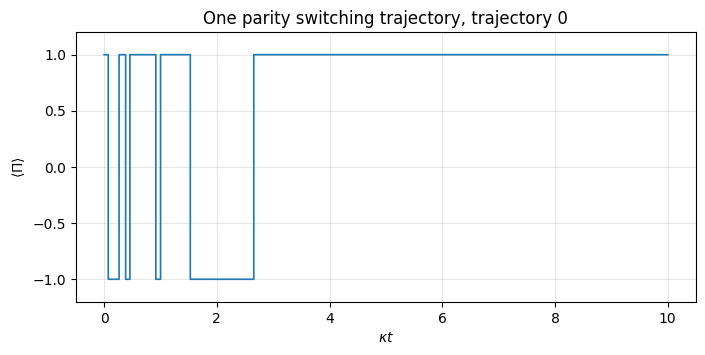

In [7]:
# Plot one individual parity trajectory.
traj_index = 0

plt.figure(figsize=(8, 3.5))
plt.step(kappa * tlist, parity_runs[traj_index], where="post", lw=1.2)
plt.xlabel(r"$\kappa t$")
plt.ylabel(r"$\langle \Pi \rangle$")
plt.title(f"One parity switching trajectory, trajectory {traj_index}")
plt.ylim(-1.2, 1.2)
plt.grid(alpha=0.3)
plt.show()


In [9]:
def count_jumps_from_parity_trace(single_trace):
    """Count parity switches using the assignment's diff/2 rule."""
    # Round to +/-1 to avoid tiny numerical deviations from exact parity values.
    s = np.sign(np.real(single_trace))
    s[s == 0] = 1
    return int(round(np.sum(np.abs(np.diff(s) / 2))))

counts_from_trace = np.array([
    count_jumps_from_parity_trace(trace) for trace in parity_runs
])

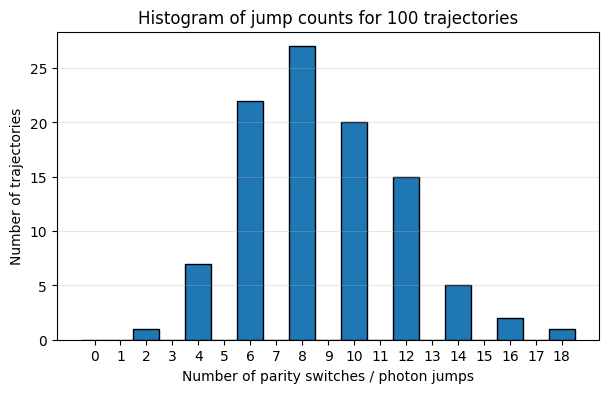

In [10]:

max_count = int(max(counts_from_trace.max(), 1))
bins = np.arange(-0.5, max_count + 1.5, 1)

plt.figure(figsize=(7, 4))
plt.hist(counts_from_trace, bins=bins, edgecolor="black")
plt.xlabel("Number of parity switches / photon jumps")
plt.ylabel("Number of trajectories")
plt.title(f"Histogram of jump counts for {Ntraj} trajectories")
plt.xticks(np.arange(0, max_count + 1, 1))
plt.grid(axis="y", alpha=0.3)
plt.show()
